In [4]:
using Pkg
include("../src/usadel_core.jl")
using Plots
using SparseArrays
using LinearAlgebra

In [5]:
#parameters and setup
Dn  = 2.0
Ds  = 2.0
ξn  = sqrt(Dn / 2.0) 
ξs  = sqrt(Ds / 2.0) 
Ln  = 20.0             
Ls1  = 10.0
Ls2 = 10.0             
dx  = 0.1              
Γin = 1e-3
T = 0.1
Tc = 1.0;

In [6]:
energies=collect(range(0.001,1.2,length=300))
x_eval=-1.5
p = setup_simulation_SNS(Ls1, Ln, Ls2, dx, 0.0, Γin, 1.0, 1.0, Dn, Ds)
Δ_sc, theta = self_consistent_delta(p,T,Tc,150,100,1e-6,0.5)
p.Δ = Δ_sc./maximum(Δ_sc)
dos1, _ = compute_DOS(energies, p, x_eval);

┌ Warning: Did not converge after 150 iterations, final max Δ change: diff
└ @ Main ~/dev/julia/usadel_1D/src/usadel_core.jl:285
┌ Warning: Did not converge for E=0.001 after 50 iterations
└ @ Main ~/dev/julia/usadel_1D/src/usadel_core.jl:233


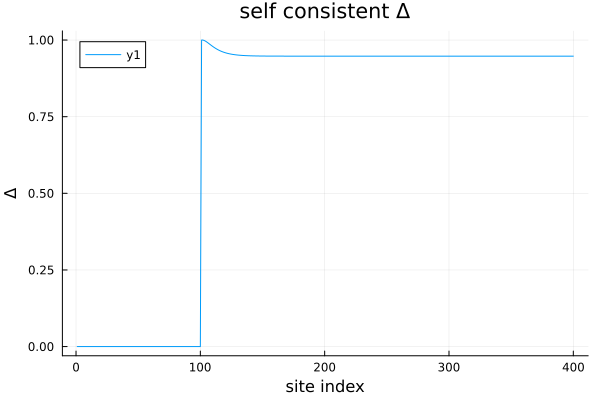

In [7]:
plt = Plots.plot(xlabel="site index", ylabel="Δ",
           title="self consistent Δ")

plot!(plt, 1:length(Δ_sc), Δ_sc./maximum(Δ_sc))

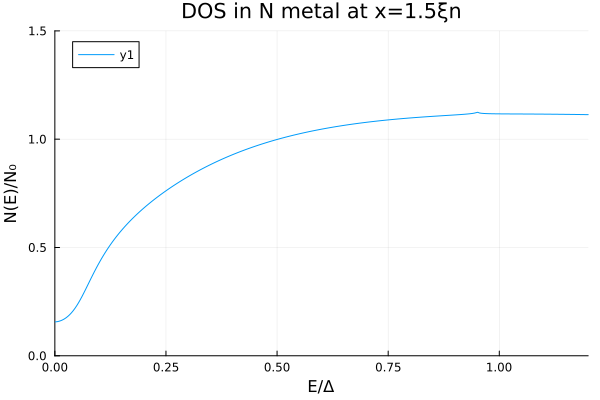

In [8]:
plt = Plots.plot(xlabel="E/Δ", ylabel="N(E)/N₀",
           title="DOS in N metal at x=1.5ξn",
           ylims=(0, 1.5), xlims=(0, 1.2),
           legend=:topleft, lw=2)

plot!(plt, energies, dos1)